*2026 Spring DSAA 2011 Maching Learning*
## Lab Note 07
*Changkai Mai, Shuyu Shen, Yifan Zhang, WeiKai Yang, Yang Luo, Yuhan Pu, Zixin Zhong* \
*Hong Kong University of Science and Technology (Guangzhou)*

**Question 1.** Cross-validation.

Cross-validation methods are useful for evaluating the performance of machine learning models while preventing overfitting.

In this task, we will implement two common cross-validation methods—**Leave-One-Out Cross-Validation (LOO-CV)** and **n-Fold Cross-Validation**—based on the multi-class classification in **LA05 Question 3**. 

**Tasks:**
- Based on your implementation of **Question 1**, build a SVM model for multi-class classification with **Iris dataset**.
    - **Dataset Source**: [Iris Dataset - Kaggle](https://www.kaggle.com/datasets/vikrishnan/iris-dataset/data)  
    - **Dataset File**: `DSAA2011-LA05-iris.csv`  
- Implement **Leave-One-Out Cross-Validation (LOO-CV)** to evaluate the model performance.
- Implement **k-Fold Cross-Validation** to evaluate the model performance (Default k=5).
- Try different values of **k** for k-Fold Cross-Validation and compare the results.

**Your solution here:**

   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
     sepal_length  sepal_width  species
23            5.1          3.3        0
139           6.9          3.1        2
12            4.8          3.0        0
71            6.1          2.8        1
136           6.3          3.4        2


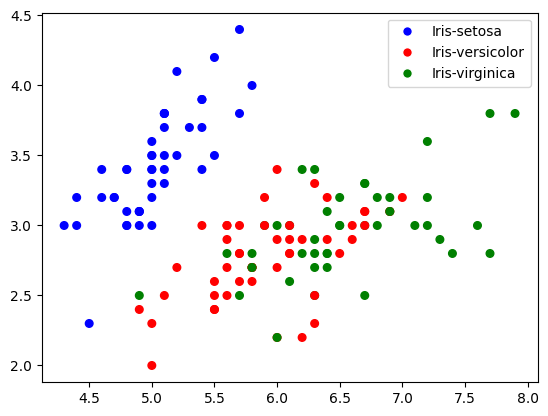

In [ ]:
#################### Your Code Here ####################
# ======================================================

#1. dataset preparation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# read and load dataset
data = pd.read_csv('DSAA2011-LA07-iris.csv', header=None)
data.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
print(data.head())
data = data[data['species'].isin(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])]
# select the first two features for simplicity
x = data.iloc[:, [0,1]]
y = data['species']
# convert the target variable to categorical values.
y = y.map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})

#Split the dataset into training and testing sets using (x,y)
from matplotlib.lines import Line2D

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.10)
print(pd.concat([x_train, y_train], axis=1, sort=False).head())

# color map
colors = {0 : 'b',
          1 : 'r',
          2: 'g'
          }
c = [colors[val] for val in y_train]
plt.scatter(x_train.iloc[:, 0], x_train.iloc[:, 1], c=c, s=30)

legend = [Line2D([0], [0], color='w', markerfacecolor='b', marker='o', label='Iris-setosa', markersize=7),
          Line2D([0], [0], color='w', markerfacecolor='r', marker='o', label='Iris-versicolor', markersize=7),
          Line2D([0], [0], color='w', markerfacecolor='g', marker='o', label='Iris-virginica', markersize=7)]

plt.legend(handles=legend, loc=1)

In [ ]:
#3. Implement Leave-One-Out Cross-Validation (LOO-CV)
from sklearn.model_selection import LeaveOneOut, KFold
from sklearn import svm
from sklearn.metrics import accuracy_score

def leave_one_out_cross_validation(x, y, model):
    loo = LeaveOneOut()
    accuracies = []

    # Loop over each data point
    for train_index, eval_index in loo.split(x):
        x_train, x_eval = x.iloc[train_index], x.iloc[eval_index]
        y_train, y_eval = y.iloc[train_index], y.iloc[eval_index]
        
        # Train and test the model
        model.fit(x_train, y_train)
        y_pred = model.predict(x_eval)
        
        # Calculate accuracy
        accuracies.append(accuracy_score(y_eval, y_pred))
    
    return np.mean(accuracies)


model = svm.SVC(C=1000, kernel='rbf')
loo_accuracy = leave_one_out_cross_validation(x_train, y_train, model)
print(f"Leave-One-Out Cross-Validation Accuracy: {loo_accuracy:.4f}")


Leave-One-Out Cross-Validation Accuracy: 0.7926


In [ ]:
# Implement k-Fold Cross-Validation
def n_fold_cross_validation(x, y, model, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    accuracies = []

    # Loop over each fold
    for train_index, eval_index in kf.split(x):
        x_train, x_eval = x.iloc[train_index], x.iloc[eval_index]
        y_train, y_eval = y.iloc[train_index], y.iloc[eval_index]
        
        # Train and test the model
        model.fit(x_train, y_train)
        y_pred = model.predict(x_eval)
        
        # Calculate accuracy
        accuracies.append(accuracy_score(y_eval, y_pred))
    
    return np.mean(accuracies)

model = svm.SVC(C=1000, kernel='rbf')
n_folds = 5
kfold_accuracy = n_fold_cross_validation(x_train, y_train, model, n_splits=n_folds)
print(f"{n_folds}-Fold Cross-Validation Accuracy: {kfold_accuracy:.4f}")


5-Fold Cross-Validation Accuracy: 0.7630


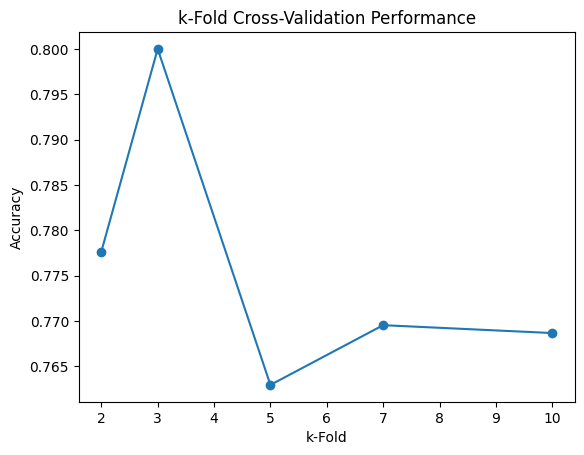

In [ ]:
# Compare different values of k for k-Fold Cross-Validation
k_values = [2, 3, 5, 7, 10]
accuracies = []

for k in k_values:
    accuracy = n_fold_cross_validation(x_train, y_train, model, n_splits=k)
    accuracies.append(accuracy)

plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('k-Fold')
plt.ylabel('Accuracy')
plt.title('k-Fold Cross-Validation Performance')
plt.show()

**Question 2.** Multiclass classification with SVM using the Wine dataset.

In the wine industry, accurate classification of wines based on their chemical properties can help with Quality control and assurance, Authentication of wine origins ,Production process optimization.

- **Dataset**: Wine Recognition Dataset from scikit-learn ([Learn more](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html#sklearn.datasets.load_wine)).
- **Task**: Multiclass classification to identify wine types based on chemical analysis.

a) Find the optimal hyperparameters for Support Vector Machine classifier using systematic grid search with cross-validation.


- Split data into training and test sets with stratification.
- Standardize features for SVM performance.
- Define comprehensive parameter grid (C, kernel, gamma, degree).
- Execute GridSearchCV with 5-fold cross-validation.
- Identify best performing model configuration.

b) Conduct thorough evaluation of the optimized SVM model using multiple metrics and visualizations for multiclass classification.


- Calculate comprehensive performance metrics (accuracy, precision, recall, F1-score).
- Generate confusion matrix and classification report.
- Visualize feature importance and model performance.

Dataset Shape: (178, 13)
Number of Features: 13
Target Classes: ['class_0' 'class_1' 'class_2']
Class Distribution: [59 71 48]
Starting GridSearchCV...
Fitting 5 folds for each of 96 candidates, totalling 480 fits

Best Parameters: {'C': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-validation Score: 0.9862
Test Set Accuracy: 0.9722
Training Accuracy: 0.9930
Test Accuracy: 0.9722
Macro Precision: 0.9778
Macro Recall: 0.9667
Macro F1-Score: 0.9710

Detailed Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



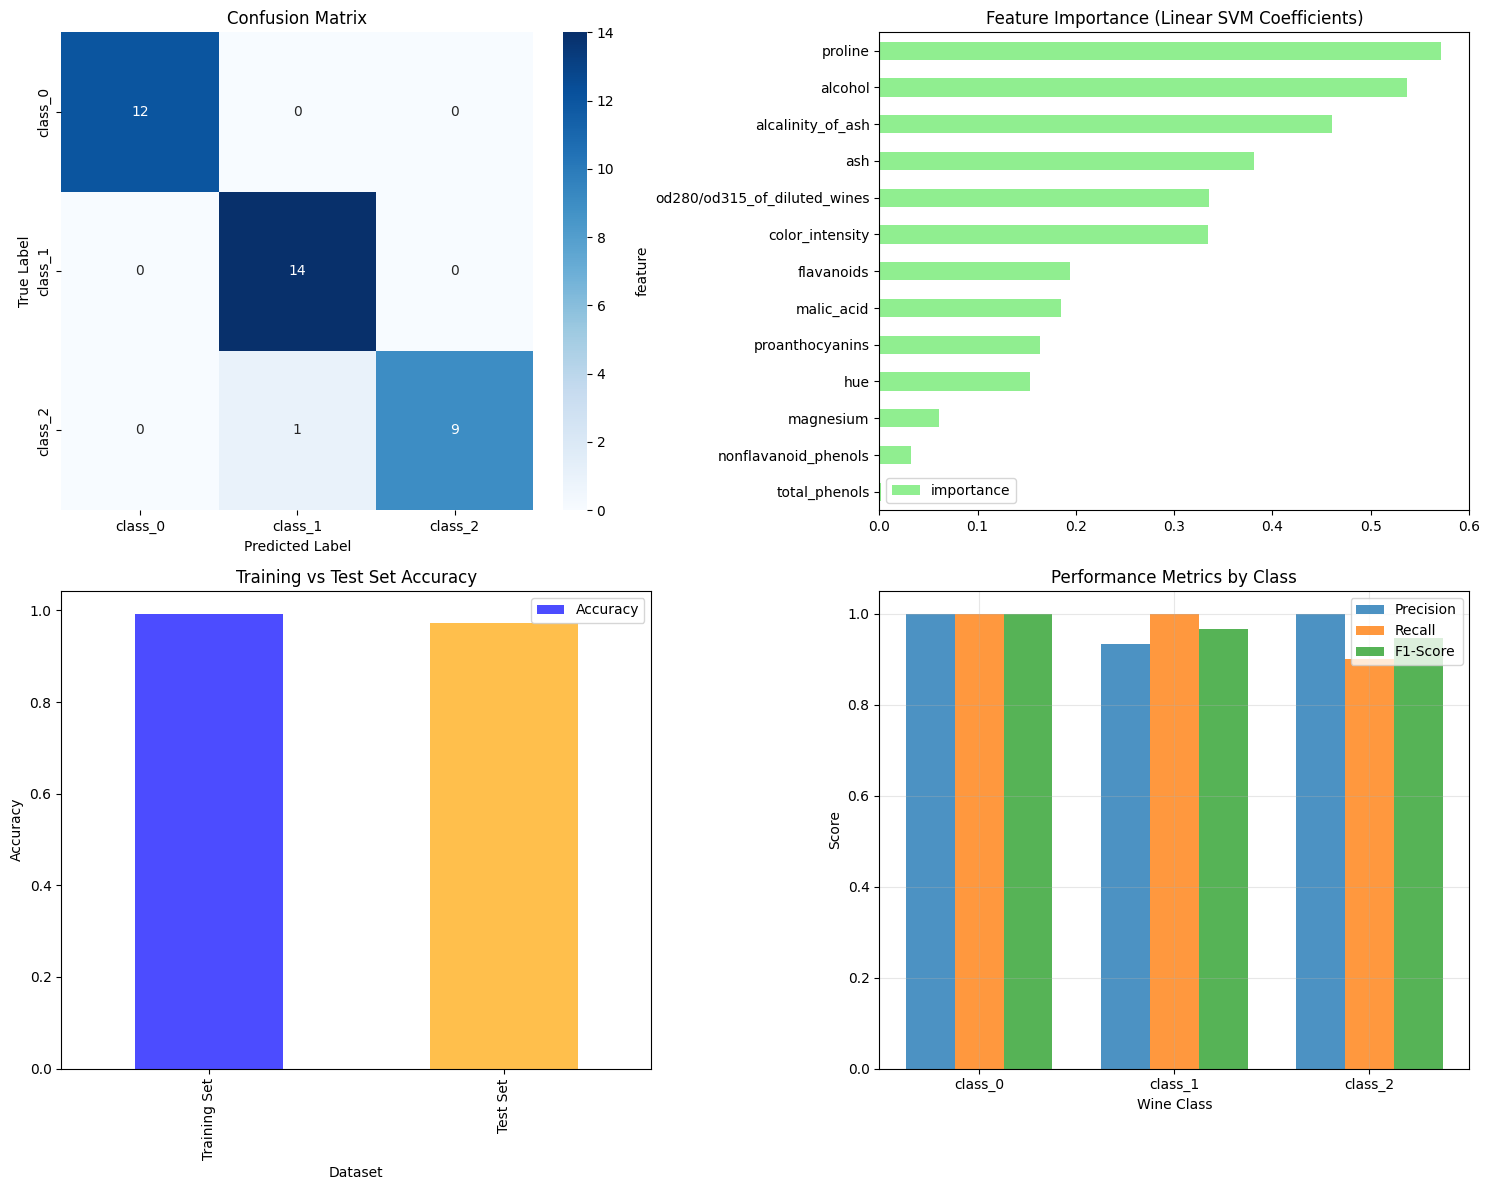


MODEL PERFORMANCE SUMMARY
Final Test Accuracy: 0.9722


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine


# Set random seed for reproducibility
np.random.seed(42)

# Load dataset
data = load_wine()
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"Dataset Shape: {X.shape}")
print(f"Number of Features: {len(feature_names)}")
print(f"Target Classes: {target_names}")
print(f"Class Distribution: {np.bincount(y)}")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, confusion_matrix, 
                           classification_report)
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Data standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define SVM parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 1],
    'degree': [2, 3]  # Only for poly kernel
}

print("Starting GridSearchCV...")
grid_search = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-validation Score: {grid_search.best_score_:.4f}")

# Test set performance
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Set Accuracy: {test_accuracy:.4f}")

# Predictions
y_train_pred = best_model.predict(X_train_scaled)
y_test_pred = best_model.predict(X_test_scaled)
y_test_proba = best_model.predict_proba(X_test_scaled)

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Multiclass precision, recall, F1 (macro average)
precision = precision_score(y_test, y_test_pred, average='macro')
recall = recall_score(y_test, y_test_pred, average='macro')
f1 = f1_score(y_test, y_test_pred, average='macro')

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")
print(f"Macro F1-Score: {f1:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=target_names))

# Visualization of results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names, ax=axes[0,0])
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_xlabel('Predicted Label')
axes[0,0].set_ylabel('True Label')

# 2. Feature Importance (based on linear SVM coefficients)
if hasattr(best_model, 'coef_'):
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': np.abs(best_model.coef_[0])  # Take coefficients for first class
    }).sort_values('importance', ascending=True)
    
    feature_importance.plot(kind='barh', x='feature', y='importance', 
                           ax=axes[0,1], color='lightgreen')
    axes[0,1].set_title('Feature Importance (Linear SVM Coefficients)')

# 3. Learning curve analysis (Training vs Test accuracy)
accuracy_comparison = pd.DataFrame({
    'Dataset': ['Training Set', 'Test Set'],
    'Accuracy': [train_accuracy, test_accuracy]
})
accuracy_comparison.plot(kind='bar', x='Dataset', y='Accuracy', 
                        ax=axes[1,0], color=['blue', 'orange'], alpha=0.7)
axes[1,0].set_title('Training vs Test Set Accuracy')
axes[1,0].set_ylabel('Accuracy')

# 4. Performance comparison across classes
class_metrics = []
for i, class_name in enumerate(target_names):
    class_precision = precision_score(y_test, y_test_pred, average=None)[i]
    class_recall = recall_score(y_test, y_test_pred, average=None)[i]
    class_f1 = f1_score(y_test, y_test_pred, average=None)[i]
    class_metrics.append({
        'Class': class_name,
        'Precision': class_precision,
        'Recall': class_recall,
        'F1-Score': class_f1
    })

metrics_df = pd.DataFrame(class_metrics)
x = np.arange(len(target_names))
width = 0.25

axes[1,1].bar(x - width, metrics_df['Precision'], width, label='Precision', alpha=0.8)
axes[1,1].bar(x, metrics_df['Recall'], width, label='Recall', alpha=0.8)
axes[1,1].bar(x + width, metrics_df['F1-Score'], width, label='F1-Score', alpha=0.8)

axes[1,1].set_xlabel('Wine Class')
axes[1,1].set_ylabel('Score')
axes[1,1].set_title('Performance Metrics by Class')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(target_names)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model summary
print("\n" + "=" * 40)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 40)
print(f"Final Test Accuracy: {test_accuracy:.4f}")

 **Question 3.** Model selection with Grid Search.

Tasks:
1. Load the [breast cancer dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html).
2. Compare SVM, and Decision Tree classifiers.
3. For each model, use GridSearchCV to find optimal hyperparameterse.
5. Evaluate and compare the best models using cross-validation.
6. Analyze which model performs best.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {np.bincount(y)}")

Dataset shape: (569, 30)
Number of classes: 2
Class distribution: [212 357]


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
# Split and scale data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
models = {

    'SVM': {
        'model': SVC(random_state=42),
        'params': {
            'C': [0.1, 1, 10, 100],
            'kernel': ['linear', 'rbf', 'poly'],
            'gamma': ['scale', 'auto', 0.001, 0.01]
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [2, 5, 10, 20],
            'min_samples_leaf': [1, 2, 4, 8],
            'criterion': ['gini', 'entropy']
        }
    }
}

# Grid Search for each model
grid_results = {}
for name, config in models.items():
    print(f"\nTraining {name}...")
    grid_search = GridSearchCV(
        config['model'], 
        config['params'], 
        cv=5, 
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_train_scaled, y_train)
    
    grid_results[name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'best_model': grid_search.best_estimator_,
        'cv_results': grid_search.cv_results_
    }
    
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best CV score: {grid_search.best_score_:.4f}")
    
    # Test set performance
    y_pred = grid_search.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)
    print(f"Test accuracy: {test_acc:.4f}")


Training SVM...
Best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV score: 0.9802
Test accuracy: 0.9825

Training Decision Tree...
Best parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV score: 0.9385
Test accuracy: 0.9211


In [ ]:
print("\n--- Model Comparison Summary ---")

comparison_df = pd.DataFrame({
    'Model': list(grid_results.keys()),
    'Best CV Score': [result['best_score'] for result in grid_results.values()],
    'Test Accuracy': [
        accuracy_score(y_test, result['best_model'].predict(X_test_scaled))
        for result in grid_results.values()
    ]
})
print("\n", comparison_df.to_string(index=False))


--- Model Comparison Summary ---

         Model  Best CV Score  Test Accuracy
          SVM       0.980220       0.982456
Decision Tree       0.938462       0.921053


**Question 4.** Bagging.

***Question Description***

We generate $N = 30$ training samples, with 2 classes and $p=5$ features, each following the standard normal distribution with pairwise correlation 0.95.

The response $Y$ is generated according to $\operatorname{Pr}(Y = 1 \mid x_1 ≤ 0.5) = 0.2$, $\operatorname{Pr}(Y = 1 \mid x_1 > 0.5) = 0.8$.

The Bayes error is 0.2. 

2000 test samples are also generated from the same population. 

We fit classification trees to the training samples and to each of 200 bootstrap samples.

You are required to understand the task and fill in the missing code in differet parts.

***Background Knowledge (How to Train and Test a Decision Tree)***

1. Initialize a decision tree:

    `decision_tree = DecisionTreeClassifier()`

2. Use the `fit` method of the decision tree to perform training, with the training data as input:

    `decision_tree.fit(X_train, y_train)`

3. Use the trained decision tree to make prediction on the test data:

    `prediction = decision_tree.predict(X_test)`


In [ ]:
# Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import scipy.interpolate as interpolate
sns.set_style('darkgrid')

***(1) Data Generation***

**Question 4.1**: Please fill in the data generating function below.  

Think about how to realize a characteristic matrix by coding

In [ ]:
np.random.seed(0)

training_set_size = 30
test_set_size = 2000

def generate_data(N):
    # Generate characteristic matrix with shape (N x 5), Cov = 0.95
    mean = np.zeros(5)
    cov = np.eye(5) * 0.05 + np.ones((5, 5)) * 0.95
    X = np.random.multivariate_normal(mean, cov, size=N)
    
    # Generate response variable Y with Pr(Y = 1|x1 ≤ 0.5) = 0.2, Pr(Y = 1|x1 > 0.5) = 0.8.
    Y = np.zeros(N)
    Y[X[:, 0] <= 0.5] = np.random.binomial(1, 0.2, np.sum(X[:, 0] <= 0.5))
    Y[X[:, 0] > 0.5] = np.random.binomial(1, 0.8, np.sum(X[:, 0] > 0.5))
    
    return X, Y

# Generate the training set and the test set, with size = 30 and 2000 respectively
X_train, y_train = generate_data(training_set_size)
X_test, y_test = generate_data(test_set_size)

***(2) Train Single Decision Tree***

**Question 4.2**: Please fill in the missing code to define a decision tree model by yourself

In [ ]:
# This is the answer for the first question
def train_model(X_train, y_train):
    tree = DecisionTreeClassifier()
    tree.fit(X_train, y_train)
    return tree

#============= Do not modify the code below =============#

original_tree = train_model(X_train, y_train)
y_pred = original_tree.predict(X_test)

original_accuracy = accuracy_score(y_test, y_pred)
print('Original Accuracy: ', original_accuracy)

Original Accuracy:  0.65


***(3) Bootstrap Sampling***

**Question 1.3**: Please fill the missing code to construct a bootstrap function

In [ ]:
def bootstrap(X_train, y_train, n_bootstrap_sample, n_estimators, return_indices=False):
    bootstrap_samples = []
    bootstrap_indices = []
    for _ in range(n_estimators):
        # Generate bootstrap sample, using the np.random.choice function, setting the parameter `replace` as true.
        indices = np.random.choice(X_train.shape[0], n_bootstrap_sample, replace=True)
        X_bootstrap = X_train[indices]
        y_bootstrap = y_train[indices]
        bootstrap_samples.append((X_bootstrap, y_bootstrap))
        bootstrap_indices.append(indices)
    if return_indices:
        return bootstrap_samples, bootstrap_indices
    return bootstrap_samples

#============= Do not modify the code below =============#

simulated_samples = bootstrap(X_train, y_train, X_train.shape[0], n_estimators=1000)
model_list = [train_model(X_train, y_train) for X_train, y_train in simulated_samples]
y_pred_list = [model.predict(X_test) for model in model_list]
expected_accuracy = np.mean([accuracy_score(y_test, y_pred) for y_pred in y_pred_list])
print('Expected Original Accuracy: ', expected_accuracy)

Expected Original Accuracy:  0.6382194999999999


***(4) Ensemble Prediction***

In [ ]:
def majority_voting(predictions):
    return np.apply_along_axis(lambda x: np.bincount(x.astype(int)).argmax(), axis=0, arr=predictions)

def bagging_predict(model_list, X):
    predictions = np.array([model.predict(X) for model in model_list])
    return majority_voting(predictions)

**Question 1.4**: Please construct 11 trees by using bootstrap we defined above.

You are required to print out the accuracy of bagged tree for data in the test set

In [ ]:
bootstrap_samples = bootstrap(X_train, y_train, X_train.shape[0], n_estimators=11)
model_list = [train_model(X_train, y_train) for X_train, y_train in bootstrap_samples]
bagged_prediction = bagging_predict(model_list, X_test)
bagged_accuracy = accuracy_score(y_test, bagged_prediction)
print(f"{bagged_accuracy=}")

bagged_accuracy=0.6685


In [ ]:
def run_experiment(X_train, y_train, n_bootstrap_samples, n_models):
    bootstrap_samples = bootstrap(X_train, y_train, n_bootstrap_samples, n_estimators=n_models)
    trees = [train_model(*training_sample) for training_sample in bootstrap_samples]
    bagged_prediction = bagging_predict(trees, X_test)
    bagged_accuracy = accuracy_score(y_test, bagged_prediction)
    return bagged_accuracy

print(run_experiment(X_train, y_train, 30, 11))

0.6975


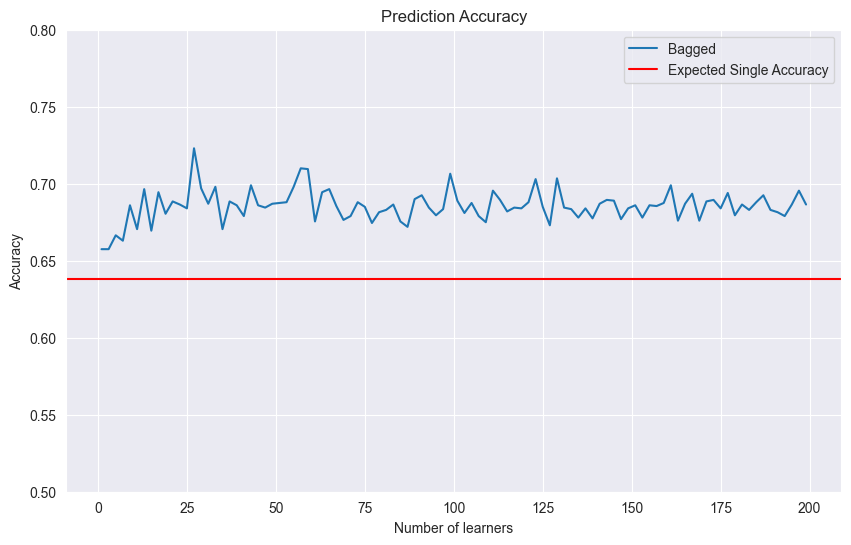

In [ ]:
#  Run experiment from 1 to 200
accuracy_scores = [run_experiment(X_train, y_train, 30, n_model) for n_model in range(1, 200, 2)]
accuracy_scores = np.array(accuracy_scores)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 200, 2), accuracy_scores, label='Bagged')
plt.axhline(y=expected_accuracy, color='r', linestyle='-', label='Expected Single Accuracy')
plt.xlabel('Number of learners')
plt.ylabel('Accuracy')
plt.ylim(.5, .8)
plt.title('Prediction Accuracy')
plt.legend()
plt.show()

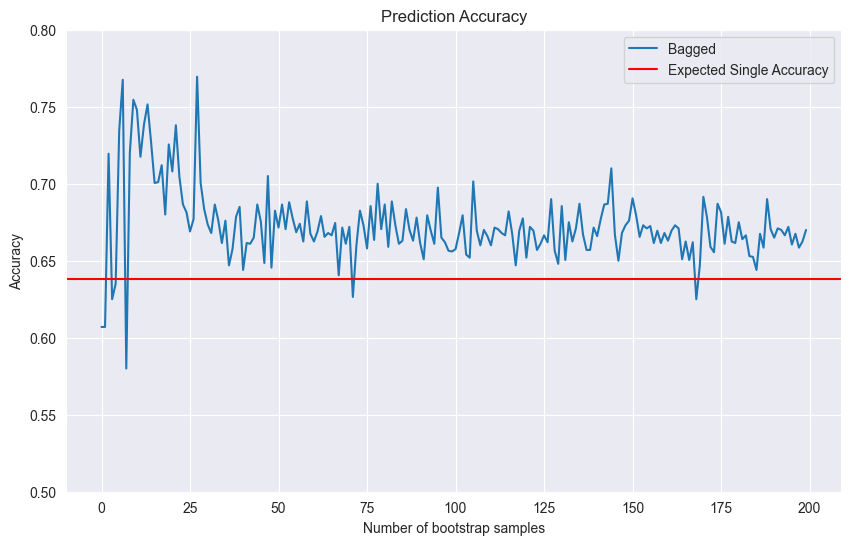

In [ ]:
#  Fix 11 trees, varing boostrap samples
accuracy_scores = [run_experiment(X_train, y_train, n_bootstrap_samples, 11) for n_bootstrap_samples in range(1, 201)]
accuracy_scores = np.array(accuracy_scores)

plt.figure(figsize=(10, 6))
plt.plot(accuracy_scores, label='Bagged')
plt.axhline(y=expected_accuracy, color='r', linestyle='-', label='Expected Single Accuracy')
plt.xlabel('Number of bootstrap samples')
plt.ylabel('Accuracy')
plt.ylim(.5, .8)
plt.title('Prediction Accuracy')
plt.legend()
plt.show()